In [6]:
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

import pickle
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("data/dataset.csv")

In [8]:
X = df["clean_text"]
y_style = df["style"]
y_tone = df["tone"]

X_train_style, X_test_style, y_train_style, y_test_style = train_test_split(
    X, y_style, test_size=0.2, random_state=42, stratify=y_style
)

X_train_tone, X_test_tone, y_train_tone, y_test_tone = train_test_split(
    X, y_tone, test_size=0.2, random_state=42, stratify=y_tone
)

pipeline = Pipeline(
    [("tfidf", TfidfVectorizer()), ("classifier", LinearSVC())]
)

param_grid = {
    "tfidf__max_features": [3000, 5000],
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "classifier__C": [0.1, 1, 10],
}


Tuning STYLE model...

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best STYLE params:
{'classifier__C': 1, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 2)}

STYLE F1-score: 0.8825

STYLE Classification Report:

              precision    recall  f1-score   support

    academic       0.90      0.95      0.93        40
    business       0.78      0.80      0.79        40
      formal       0.85      0.70      0.77        40
    informal       0.89      1.00      0.94        40
    literaly       1.00      0.97      0.99        40

    accuracy                           0.89       200
   macro avg       0.88      0.89      0.88       200
weighted avg       0.88      0.89      0.88       200



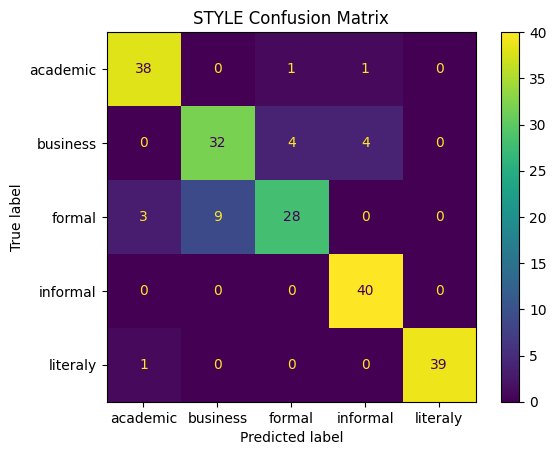


Saved style_model.pkl


In [9]:
print("\nTuning STYLE model...\n")

grid_style = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    verbose=2,
    n_jobs=-1,
)

grid_style.fit(X_train_style, y_train_style)
best_style_model = grid_style.best_estimator_

print("Best STYLE params:")
print(grid_style.best_params_)

style_predictions = best_style_model.predict(X_test_style)
style_f1 = f1_score(y_test_style, style_predictions, average="weighted")
print(f"\nSTYLE F1-score: {style_f1:.4f}")

print("\nSTYLE Classification Report:\n")
print(classification_report(y_test_style, style_predictions))

style_cm = confusion_matrix(y_test_style, style_predictions)
disp_style = ConfusionMatrixDisplay(
    confusion_matrix=style_cm, display_labels=best_style_model.classes_
)
disp_style.plot()
plt.title("STYLE Confusion Matrix")
plt.show()

with open("saving/style_model.pkl", "wb") as f:
    pickle.dump(best_style_model, f)
print("\nSaved style_model.pkl")


Tuning TONE model...

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best TONE params:
{'classifier__C': 10, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 1)}

TONE F1-score: 0.9545

TONE Classification Report:

              precision    recall  f1-score   support

  aggressive       0.97      0.97      0.97        40
    friendly       0.95      1.00      0.98        40
     neutral       0.93      0.93      0.93        40
   sarcastic       0.95      0.88      0.91        40
      urgent       0.98      1.00      0.99        40

    accuracy                           0.95       200
   macro avg       0.95      0.96      0.95       200
weighted avg       0.95      0.95      0.95       200



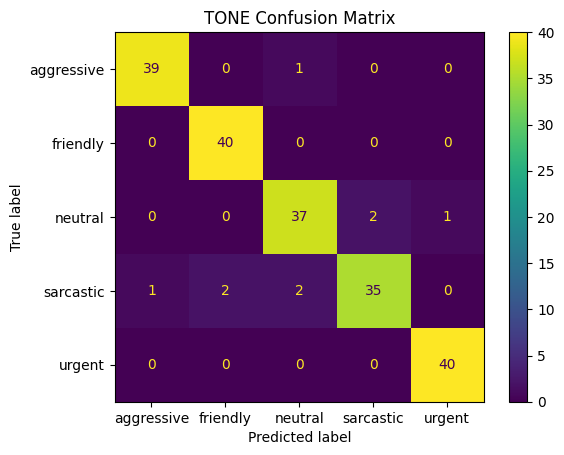


Saved tone_model.pkl


In [10]:
print("\nTuning TONE model...\n")

grid_tone = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    verbose=2,
    n_jobs=-1,
)

grid_tone.fit(X_train_tone, y_train_tone)
best_tone_model = grid_tone.best_estimator_

print("Best TONE params:")
print(grid_tone.best_params_)

tone_predictions = best_tone_model.predict(X_test_tone)
tone_f1 = f1_score(y_test_tone, tone_predictions, average="weighted")
print(f"\nTONE F1-score: {tone_f1:.4f}")

print("\nTONE Classification Report:\n")
print(classification_report(y_test_tone, tone_predictions))

tone_cm = confusion_matrix(y_test_tone, tone_predictions)
disp_tone = ConfusionMatrixDisplay(
    confusion_matrix=tone_cm, display_labels=best_tone_model.classes_
)
disp_tone.plot()
plt.title("TONE Confusion Matrix")
plt.show()

with open("saving/tone_model.pkl", "wb") as f:
    pickle.dump(best_tone_model, f)
print("\nSaved tone_model.pkl")